# Aeromagnetic Inversion with Neural Operators and Bayesian Optimization

This notebook demonstrates a complete pipeline for geophysical inversion of aeromagnetic data, combining probabilistic geological priors, physics-based simulation, learned surrogate models, and Bayesian optimization.

**Based on:** [williamjsdavis/GP-cubed](https://github.com/williamjsdavis/GP-cubed) (MIT License) — specifically the [`neural-operator-geophysics`](https://github.com/williamjsdavis/GP-cubed/tree/main/neural-operator-geophysics) subdirectory. Sections 1–3 closely follow the original `fno_aeromag_demo.ipynb`, with adaptations for Apple Silicon (MPS). The `src.py` helper library is copied directly from that repository. Section 4 is an original extension.

---

## Pipeline Overview

| Section | Method | Output |
|---------|--------|--------|
| 1 | Gaussian Process prior (GPyTorch) | 3D susceptibility realizations |
| 2 | SimPEG forward simulation | 2D aeromagnetic anomaly maps |
| 3 | Fourier Neural Operator (neuralop) | Fast surrogate for the forward model |
| 4 | Bayesian Optimization (BoTorch) | Recovered subsurface parameters |

---

## Section 1: GP Prior for 3D Magnetic Susceptibility

We model the subsurface as a 3D field of magnetic susceptibility values drawn from a Gaussian process prior. The prior uses a composite Matérn kernel — a smooth background component with long length-scale, and a rougher target component with shorter length-scale — to produce geologically realistic heterogeneous fields.

The susceptibility values are modelled in log-space (so `exp(sample)` gives physical SI units), with a mean around -4 corresponding to ~0.018 SI, typical for weakly magnetic crustal rocks.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

#from src import ThreeDimAnisoGP, CompositeFieldModel

# We will also need BoTorch and GPyTorch for our extension
import gpytorch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="neuralop")
warnings.filterwarnings("ignore", message="An output with one or more elements was resized")




/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src import ThreeDimAnisoGP, CompositeFieldModel

In [3]:
from gpytorch.kernels import MaternKernel, ScaleKernel

class MaternGeologyPrior(ThreeDimAnisoGP):
    def __init__(self, mean_value, variance_value, covar_length, nu=1.5):
        super().__init__(mean_value, variance_value, covar_length)
        # Replace the kernel the parent's forward() actually uses
        self.covar_module_projection = ScaleKernel(
            MaternKernel(nu=nu, ard_num_dims=3)
        )
        self.covar_module_projection.base_kernel.lengthscale = covar_length
        self.covar_module_projection.outputscale = variance_value

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [5]:
# Define 3D grid
grid_shape = (24, 24, 6)
xmin, xmax = -50.0, 50.0
ymin, ymax = -50.0, 50.0
zmin, zmax = -10.0, 10.0

x = np.linspace(xmin, xmax, grid_shape[0])
y = np.linspace(ymin, ymax, grid_shape[1])
z = np.linspace(zmin, zmax, grid_shape[2])

xx, yy, zz = np.meshgrid(x, y, z, indexing="ij")
grid_points = np.stack([xx.ravel(), yy.ravel(), zz.ravel()], axis=-1)

# Push to device (MPS or CPU) immediately
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32).to(device)

In [6]:
# 1. Define the helper function (must be defined before being called!)
def sample_realization(model, grid_points, n_samples=1):
    """
    Calls the model to get a distribution-like object and samples from it.
    """
    with torch.no_grad():
        # grid_points should already be on 'device' (MPS)
        dist = model(grid_points) 
        sample_shape = torch.Size([n_samples])
        samples = dist.sample(sample_shape)
    return samples

# 2. Initialize your Matérn models
background_model = MaternGeologyPrior(
    mean_value=-4.0, variance_value=0.2, covar_length=160.0, nu=2.5
).to(device)

target_diff_model = MaternGeologyPrior(
    mean_value=0.0, variance_value=1.0, covar_length=20.0, nu=1.5
).to(device)

# 3. Setup the composite wrapper
gp_model = CompositeFieldModel(
    background_model,
    target_diff_model,
    blend_radius=20.0,
)

# 4. Generate samples
n_models = 2
samples = sample_realization(gp_model, grid_points_torch, n_samples=n_models)

# 5. Extract min/max for plotting (moving back to CPU for numpy)
samples_cpu = samples.cpu()
vmin, vmax = samples_cpu.min().item(), samples_cpu.max().item()

print(f"Successfully generated {n_models} realizations.")
print(f"Susceptibility range: {vmin:.4f} to {vmax:.4f}")

/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


Successfully generated 2 realizations.
Susceptibility range: -4.9003 to -2.1405


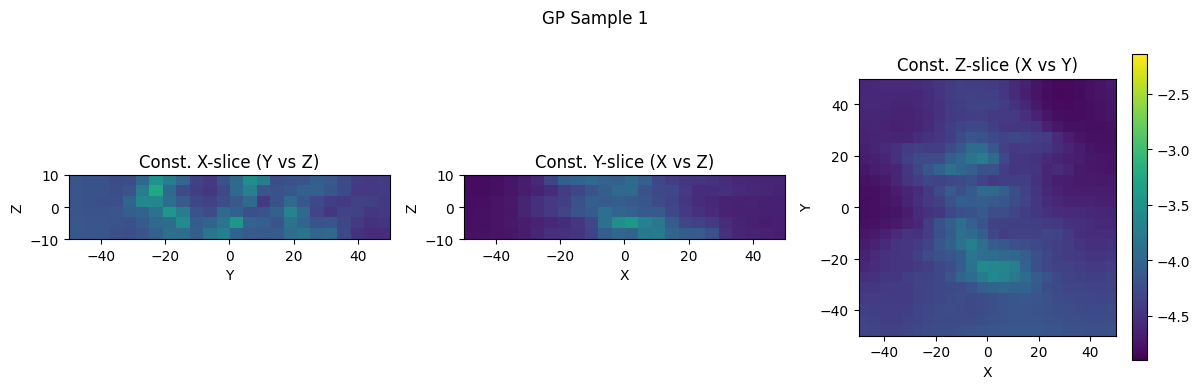

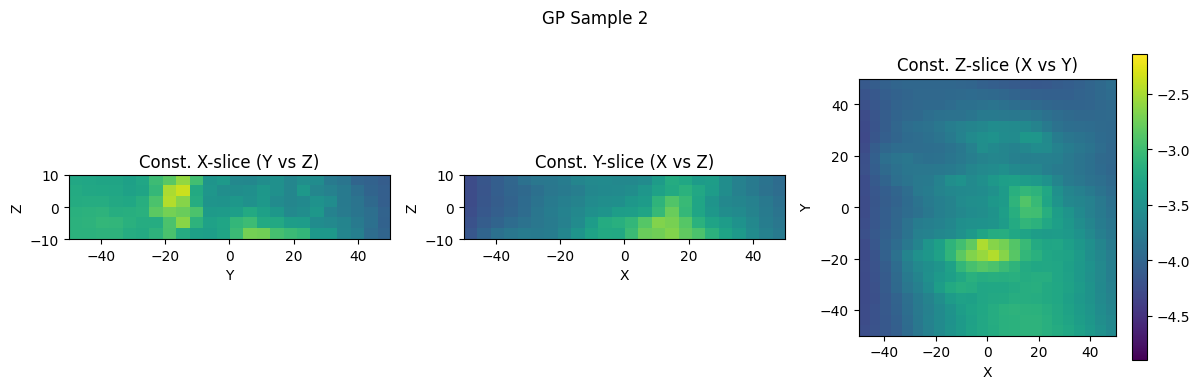

In [7]:
# Visualize cross-sections
for i in range(n_models):
    model_3d = samples[i].cpu().reshape(grid_shape).numpy()
    plt.figure(figsize=(12, 4))

    # 1. Constant X-slice (Plane Y-Z)
    # We want Y on Horizontal (Dim 1), Z on Vertical (Dim 2)
    # Current slice shape: (Y, Z). Transpose -> (Z, Y) so rows=Z (vertical)
    plt.subplot(1, 3, 1)
    plt.imshow(
        model_3d[grid_shape[0] // 2, :, :].T,
        origin="lower",
        extent=(ymin, ymax, zmin, zmax),
        vmin=vmin,
        vmax=vmax,
    )
    plt.title("Const. X-slice (Y vs Z)")
    plt.xlabel("Y")
    plt.ylabel("Z")

    # 2. Constant Y-slice (Plane X-Z)
    # We want X on Horizontal (Dim 0), Z on Vertical (Dim 2)
    # Current slice shape: (X, Z). Transpose -> (Z, X) so rows=Z (vertical)
    plt.subplot(1, 3, 2)
    plt.imshow(
        model_3d[:, grid_shape[1] // 2, :].T,
        origin="lower",
        extent=(xmin, xmax, zmin, zmax),
        vmin=vmin,
        vmax=vmax,
    )
    plt.title("Const. Y-slice (X vs Z)")
    plt.xlabel("X")
    plt.ylabel("Z")

    # 3. Constant Z-slice (Plane X-Y)
    # We want X on Horizontal (Dim 0), Y on Vertical (Dim 1)
    # Current slice shape: (X, Y). Transpose -> (Y, X) so rows=Y (vertical)
    plt.subplot(1, 3, 3)
    plt.imshow(
        model_3d[:, :, grid_shape[2] // 2].T,
        origin="lower",
        extent=(xmin, xmax, ymin, ymax),
        vmin=vmin,
        vmax=vmax,
    )
    plt.title("Const. Z-slice (X vs Y)")
    plt.xlabel("X")
    plt.ylabel("Y")

    plt.suptitle(f"GP Sample {i + 1}")
    plt.tight_layout()
    plt.colorbar(orientation="vertical")
    plt.show()

---

## Section 2: Training Data Generation via SimPEG Forward Simulation

To train a surrogate model, we need paired examples of (susceptibility field → magnetic anomaly). We generate these using SimPEG's integral formulation for the total magnetic intensity (TMI) anomaly.

Each training sample is produced by:
1. Drawing a 3D susceptibility field from the GP prior
2. Running the SimPEG forward model to compute the 2D aeromagnetic anomaly at a simulated flight height of 5 m above the domain

We generate 600 pairs and split 80/20 into training and validation sets. The dataset is saved to disk to avoid regenerating it on each run.

In [8]:
# Section 2 imports
import torch
import numpy as np
from neuralop.models import FNO
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from discretize import TensorMesh
from simpeg.potential_fields import magnetics
from simpeg import maps

In [9]:
# Helper function: SimPEG forward wrapper
def simulate_magnetic_response(susc_model, mesh, obs_xyz):
    """
    Compute magnetic anomaly response for a given susceptibility model.

    Parameters
    ----------
    susc_model : ndarray
        Flattened susceptibility values (SI units)
    mesh : TensorMesh
        SimPEG mesh
    obs_xyz : ndarray
        Observation locations (N x 3)

    Returns
    -------
    ndarray
        Predicted magnetic anomaly at observation points
    """
    receiver = magnetics.receivers.Point(obs_xyz, components=["tmi"])
    source_field = magnetics.sources.UniformBackgroundField(
        receiver_list=[receiver], amplitude=50000, inclination=60, declination=-30
    )
    survey = magnetics.survey.Survey(source_field)
    model_map = maps.IdentityMap(nP=mesh.nC)
    simulation = magnetics.simulation.Simulation3DIntegral(
        survey=survey,
        mesh=mesh,
        model_type="scalar",
        chiMap=model_map,
        store_sensitivities="forward_only",
    )
    dpred = simulation.dpred(susc_model)
    return dpred

In [10]:
# Dataset class for training data generation
class AeroMagDataset(Dataset):
    """
    Generate training pairs: 3D susceptibility → 2D magnetic anomaly
    """

    def __init__(
        self,
        gp_model,
        grid_points,
        grid_shape,
        physical_bounds,
        n_samples=100,
        obs_shape=(24, 24),
        obs_height=0.0,
        obs_padding=0.0,
    ):
        self.gp_model = gp_model
        self.grid_points = grid_points
        self.grid_shape = grid_shape
        self.physical_bounds = physical_bounds
        self.n_samples = n_samples
        self.obs_shape = obs_shape
        self.obs_height = obs_height
        self.obs_padding = obs_padding  # Padding around edges (in domain units)
        self.samples = []
        self.obs_xyz = None  # Will be set in generate()
        self.mesh = None  # Will be set in generate()
        self.generate()

    def generate(self):
        """Generate training data using GP prior and SimPEG forward model"""
        # Set up mesh matching Section 1 grid
        xmin, xmax = self.physical_bounds["x"]
        ymin, ymax = self.physical_bounds["y"]
        zmin, zmax = self.physical_bounds["z"]

        hx = np.ones(self.grid_shape[0]) * (xmax - xmin) / self.grid_shape[0]
        hy = np.ones(self.grid_shape[1]) * (ymax - ymin) / self.grid_shape[1]
        hz = np.ones(self.grid_shape[2]) * (zmax - zmin) / self.grid_shape[2]

        self.mesh = TensorMesh([hx, hy, hz], x0=[xmin, ymin, zmin])

        # Create observation grid with padding from edges
        x_obs = np.linspace(
            xmin + self.obs_padding, xmax - self.obs_padding, self.obs_shape[0]
        )
        y_obs = np.linspace(
            ymin + self.obs_padding, ymax - self.obs_padding, self.obs_shape[1]
        )
        xx_obs, yy_obs = np.meshgrid(x_obs, y_obs, indexing="ij")
        self.obs_xyz = np.c_[
            xx_obs.ravel(), yy_obs.ravel(), np.full(xx_obs.size, self.obs_height)
        ]

        print(f"Generating {self.n_samples} training samples...")
        print(
            f"  Observation area: x=[{x_obs[0]:.3f}, {x_obs[-1]:.3f}], "
            f"y=[{y_obs[0]:.3f}, {y_obs[-1]:.3f}], z={self.obs_height}"
        )
        for i in range(self.n_samples):
            # Sample from GP model (returns log-space values)
            with torch.no_grad():
                dist = self.gp_model(self.grid_points)
                log_sample = dist.sample(torch.Size([1])).squeeze().cpu().numpy()

            # Convert from log-space to physical susceptibility (SI units)
            # Models have mean ~ -4, so exp(-4) ≈ 0.018 SI
            susc_model_3d = np.exp(log_sample).reshape(self.grid_shape)

            # IMPORTANT: SimPEG expects Fortran-order (F-order) for model arrays
            # We store in 3D C-order for convenience, but flatten with F-order for SimPEG
            susc_model_flat = susc_model_3d.ravel(order="F")

            # Run SimPEG forward simulation
            dpred = simulate_magnetic_response(susc_model_flat, self.mesh, self.obs_xyz)

            # Store 3D model (C-order) and 2D anomaly
            self.samples.append((susc_model_3d, dpred.reshape(self.obs_shape)))

            if (i + 1) % 20 == 0:
                print(f"  Generated {i + 1}/{self.n_samples} samples")

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # (1, nx, ny, nz)
        y = torch.tensor(y, dtype=torch.float32).unsqueeze(0)  # (1, nx_obs, ny_obs)
        return x, y

In [11]:
# Define the physical bounds dictionary based on our linspace limits
physical_bounds = {
    "x": (-50.0, 50.0),
    "y": (-50.0, 50.0),
    "z": (-10.0, 10.0)
}

# Create the dataset
# Start with a smaller n_samples (like 50) to make sure it runs fast on your Mac first
dataset = AeroMagDataset(
    gp_model=gp_model,
    grid_points=grid_points_torch,
    grid_shape=grid_shape,
    physical_bounds=physical_bounds,
    n_samples=600,          # Adjust based on how long you want to wait
    obs_shape=(24, 24),
    obs_height=5.0,        # Flying the 'sensor' 5 units above the ground
    obs_padding=5.0        # Keep sensor away from the very edge to avoid boundary artifacts
)

# Split into training and validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=5, shuffle=False)

Generating 600 training samples...
  Observation area: x=[-45.000, 45.000], y=[-45.000, 45.000], z=5.0


/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


  Generated 20/600 samples
  Generated 40/600 samples
  Generated 60/600 samples
  Generated 80/600 samples
  Generated 100/600 samples
  Generated 120/600 samples
  Generated 140/600 samples
  Generated 160/600 samples
  Generated 180/600 samples
  Generated 200/600 samples
  Generated 220/600 samples
  Generated 240/600 samples
  Generated 260/600 samples
  Generated 280/600 samples
  Generated 300/600 samples
  Generated 320/600 samples
  Generated 340/600 samples
  Generated 360/600 samples
  Generated 380/600 samples
  Generated 400/600 samples
  Generated 420/600 samples
  Generated 440/600 samples
  Generated 460/600 samples
  Generated 480/600 samples
  Generated 500/600 samples
  Generated 520/600 samples
  Generated 540/600 samples
  Generated 560/600 samples
  Generated 580/600 samples
  Generated 600/600 samples


In [12]:
# Save dataset to disk so you don't have to regenerate
torch.save(dataset, "aeromag_dataset.pt")
print("Saved to aeromag_dataset.pt")

# To reload later instead of regenerating, run:
# dataset = torch.load("aeromag_dataset.pt", weights_only=False)
# train_size = int(0.8 * len(dataset))
# val_size = len(dataset) - train_size
# train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
# train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=5, shuffle=False)

Saved to aeromag_dataset.pt


In [13]:
# To reload later instead of regenerating, run:
dataset = torch.load("aeromag_dataset.pt", weights_only=False)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=5, shuffle=False)

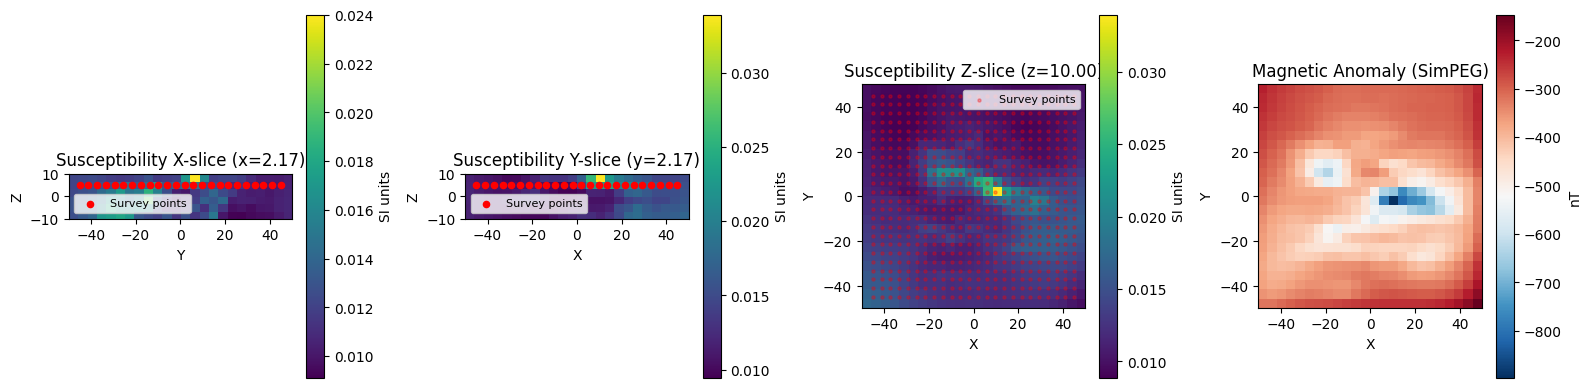

Susceptibility range: [0.0086, 0.0339] SI units
Magnetic anomaly range: [-897.00, -146.96] nT
Observation grid: 24x24 points at z=5.0
Mesh: 24x24x6 cells


In [14]:
# Validation: Visualize a training sample
# Check that the forward simulation makes sense
sample_idx = 0
x_sample, y_sample = dataset[sample_idx]
susc_3d = x_sample.squeeze().numpy()  # (24, 24, 6)
mag_2d = y_sample.squeeze().numpy()  # (24, 24)

# Get observation locations from dataset
obs_xyz = dataset.obs_xyz
xx_obs = obs_xyz[:, 0].reshape(dataset.obs_shape)
yy_obs = obs_xyz[:, 1].reshape(dataset.obs_shape)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# 1. X-slice (middle of domain)
x_idx = grid_shape[0] // 2
im1 = axes[0].imshow(
    susc_3d[x_idx, :, :].T,
    origin="lower",
    extent=(ymin, ymax, zmin, zmax),
    cmap="viridis",
)
# Project survey points onto this slice
axes[0].scatter(
    yy_obs[x_idx, :],
    np.full(grid_shape[1], dataset.obs_height),
    c="red",
    s=20,
    marker="o",
    label="Survey points",
)
axes[0].set_xlabel("Y")
axes[0].set_ylabel("Z")
axes[0].set_title(f"Susceptibility X-slice (x={x[x_idx]:.2f})")
axes[0].legend(fontsize=8)
plt.colorbar(im1, ax=axes[0], label="SI units")

# 2. Y-slice (middle of domain)
y_idx = grid_shape[1] // 2
im2 = axes[1].imshow(
    susc_3d[:, y_idx, :].T,
    origin="lower",
    extent=(xmin, xmax, zmin, zmax),
    cmap="viridis",
)
axes[1].scatter(
    xx_obs[:, y_idx],
    np.full(grid_shape[0], dataset.obs_height),
    c="red",
    s=20,
    marker="o",
    label="Survey points",
)
axes[1].set_xlabel("X")
axes[1].set_ylabel("Z")
axes[1].set_title(f"Susceptibility Y-slice (y={y[y_idx]:.2f})")
axes[1].legend(fontsize=8)
plt.colorbar(im2, ax=axes[1], label="SI units")

# 3. Z-slice (top of domain)
z_idx = -1  # Top slice
im3 = axes[2].imshow(
    susc_3d[:, :, z_idx].T,
    origin="lower",
    extent=(xmin, xmax, ymin, ymax),
    cmap="viridis",
)
axes[2].scatter(
    obs_xyz[:, 0], obs_xyz[:, 1], c="red", s=5, alpha=0.3, label="Survey points"
)
axes[2].set_xlabel("X")
axes[2].set_ylabel("Y")
axes[2].set_title(f"Susceptibility Z-slice (z={z[z_idx]:.2f})")
axes[2].legend(fontsize=8)
plt.colorbar(im3, ax=axes[2], label="SI units")

# 4. Magnetic anomaly (SimPEG result)
im0 = axes[3].imshow(
    mag_2d.T, origin="lower", extent=(xmin, xmax, ymin, ymax), cmap="RdBu_r"
)
axes[3].set_xlabel("X")
axes[3].set_ylabel("Y")
axes[3].set_title("Magnetic Anomaly (SimPEG)")
plt.colorbar(im0, ax=axes[3], label="nT")

plt.tight_layout()
plt.show()

print(f"Susceptibility range: [{susc_3d.min():.4f}, {susc_3d.max():.4f}] SI units")
print(f"Magnetic anomaly range: [{mag_2d.min():.2f}, {mag_2d.max():.2f}] nT")
print(
    f"Observation grid: {dataset.obs_shape[0]}x{dataset.obs_shape[1]} points at z={dataset.obs_height}"
)
print(f"Mesh: {grid_shape[0]}x{grid_shape[1]}x{grid_shape[2]} cells")

---

## Section 3: FNO Surrogate Training

SimPEG's forward simulation is accurate but slow — too slow to call thousands of times inside an optimization loop. We replace it with a **Fourier Neural Operator (FNO)**, which learns the mapping from 3D susceptibility fields to 2D anomaly maps.

The FNO operates directly in frequency space, making it resolution-independent and well-suited for PDE-like operators. Our architecture takes a `(1, 24, 24, 6)` susceptibility volume and outputs a `(1, 24, 24, 6)` field, from which we extract the top z-slice as the predicted 2D anomaly.

Training uses a relative L2 loss and runs on Apple MPS for acceleration.

In [15]:
# Define FNO model
# Input: 3D susceptibility field (24, 24, 6)
# Output: 2D magnetic anomaly field (24, 24)
fno = FNO(
    n_modes=(12, 12, 4),  # Fourier modes for 3D input
    hidden_channels=32,
    in_channels=1,
    out_channels=1,
    n_layers=4,
).to(device)

print(f"FNO model created with {sum(p.numel() for p in fno.parameters()):,} parameters")

FNO model created with 1,782,689 parameters


In [16]:
# Training loop
optimizer = torch.optim.Adam(fno.parameters(), lr=1e-3)
train_losses = []
val_losses = []
n_epochs = 20
n_display = 1

print(f"Training  FNO surrogate on device: {device}")
for epoch in range(n_epochs):
    # Training phase
    fno.train()
    epoch_train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        # FNO expects (batch, channels, nx, ny, nz)
        pred_3d = fno(x_batch)  # Output: (batch, 1, 24, 24, 6)
        # Take top slice (z=-1, closest to observation plane at z=0.1)
        pred = pred_3d[..., -1]  # Output: (batch, 1, 24, 24)
        diff = pred - y_batch
        numerator = torch.sqrt(torch.sum(diff**2, dim=(1, 2, 3)))
        demominator = torch.sqrt(torch.sum(y_batch**2, dim=(1, 2, 3)))
        loss = torch.mean(numerator / (demominator + 1e-8))
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation phase
    fno.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            pred_3d = fno(x_batch)
            pred = pred_3d[..., -1]
            diff = pred - y_batch
            numerator = torch.sqrt(torch.sum(diff**2, dim=(1, 2, 3)))
            demominator = torch.sqrt(torch.sum(y_batch**2, dim=(1, 2, 3)))
            loss = torch.mean(numerator / (demominator + 1e-8))
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % n_display == 0:
        print(
            f"Epoch {epoch + 1}/{n_epochs}, "
            f"Train Loss: {avg_train_loss:.4e}, "
            f"Val Loss: {avg_val_loss:.4e}"
        )

Training  FNO surrogate on device: mps


/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [5, 32, 24, 24, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [5, 32, 24, 24, 6]. This behavior is deprecated, and in a future PyTorch release outp

Epoch 1/20, Train Loss: 7.3803e-01, Val Loss: 4.6584e-01
Epoch 2/20, Train Loss: 4.4666e-01, Val Loss: 4.5150e-01
Epoch 3/20, Train Loss: 4.3646e-01, Val Loss: 5.0168e-01
Epoch 4/20, Train Loss: 4.1814e-01, Val Loss: 4.0884e-01
Epoch 5/20, Train Loss: 3.8598e-01, Val Loss: 3.4174e-01
Epoch 6/20, Train Loss: 2.9293e-01, Val Loss: 2.5496e-01
Epoch 7/20, Train Loss: 2.5371e-01, Val Loss: 2.4021e-01
Epoch 8/20, Train Loss: 2.2429e-01, Val Loss: 2.1193e-01
Epoch 9/20, Train Loss: 2.0403e-01, Val Loss: 2.3441e-01
Epoch 10/20, Train Loss: 1.9885e-01, Val Loss: 2.1905e-01
Epoch 11/20, Train Loss: 1.8689e-01, Val Loss: 1.8707e-01
Epoch 12/20, Train Loss: 1.7449e-01, Val Loss: 1.7595e-01
Epoch 13/20, Train Loss: 1.7056e-01, Val Loss: 1.8109e-01
Epoch 14/20, Train Loss: 1.6208e-01, Val Loss: 1.7581e-01
Epoch 15/20, Train Loss: 1.5444e-01, Val Loss: 1.6477e-01
Epoch 16/20, Train Loss: 1.3953e-01, Val Loss: 1.9432e-01
Epoch 17/20, Train Loss: 1.3357e-01, Val Loss: 1.6596e-01
Epoch 18/20, Train Loss

In [17]:
torch.save(fno.state_dict(), "fno_weights.pt")
print("Saved FNO weights to fno_weights.pt")


Saved FNO weights to fno_weights.pt


---

## Section 4: Bayesian Inversion with BoTorch

With a trained FNO surrogate as our fast forward model, we can now solve the **inverse problem**: given an observed aeromagnetic anomaly map, recover the subsurface parameters that produced it.

We parameterize the subsurface as a Gaussian blob with 5 parameters — position (x₀, y₀, z₀), radius, and log-amplitude — and define the objective as the negative MSE between the FNO's predicted anomaly and the observed data.

**Why Bayesian Optimization?** The FNO forward pass is fast but the loss landscape is non-convex and potentially noisy. BoTorch fits a GP surrogate over the objective and uses an Upper Confidence Bound (UCB) acquisition function to balance exploration and exploitation, finding good parameter estimates with far fewer evaluations than a grid search.

The BoTorch GP runs on CPU with float64 (its preferred format), while the FNO forward passes run on MPS.

In [18]:
import torch

# Physical bounds (matches your grid)
# x, y in [-50, 50], z in [-10, 10]

def make_blob_field(theta, grid_points, grid_shape, background=0.018):
    """
    Build a 3D susceptibility field as background + Gaussian blob.

    theta: tensor of shape (5,) = (x0, y0, z0, radius, log_amplitude)
    grid_points: (N, 3) tensor of voxel centers, on the right device
    grid_shape: e.g. (24, 24, 6)
    background: constant background susceptibility (SI units)

    Returns: (1, 1, nx, ny, nz) tensor on the same device as grid_points
    """
    x0, y0, z0, radius, log_amp = theta[0], theta[1], theta[2], theta[3], theta[4]
    amplitude = torch.exp(log_amp)

    centers = torch.stack([x0, y0, z0])              # (3,)
    diff = grid_points - centers                      # (N, 3)
    r2 = (diff ** 2).sum(dim=-1)                      # (N,)
    blob = amplitude * torch.exp(-r2 / (2 * radius ** 2))

    chi = background + blob
    return chi.reshape(1, 1, *grid_shape)

In [19]:
# Pick a "true" blob
theta_true = torch.tensor([15.0, -10.0, -3.0, 8.0, torch.log(torch.tensor(0.5))],
                         dtype=torch.float32, device=device)

# Build the true field and forward-simulate via the FNO
chi_true = make_blob_field(theta_true, grid_points_torch, grid_shape)

with torch.no_grad():
    d_obs_pure = fno(chi_true)[..., -1]
    noise_level = 0.02 * d_obs_pure.std()
    d_obs = d_obs_pure + torch.randn_like(d_obs_pure) * noise_level

print(f"d_obs std: {d_obs.std().item():.4e}")
print(f"noise level: {noise_level.item():.4e}")
print(f"SNR: {(d_obs_pure.std() / noise_level).item():.1f}")

d_obs std: 6.9082e+02
noise level: 1.3807e+01
SNR: 50.0


/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 32, 24, 24, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 32, 24, 24, 6]. This behavior is deprecated, and in a future PyTorch release outp

In [20]:
def blob_inversion_objective(theta_batch):
    """
    Compute -MSE(fno(chi(theta)), d_obs) for one or more theta vectors.

    theta_batch: (B, 5) tensor on any device/dtype (BoTorch passes float64 on CPU)
    Returns: (B, 1) tensor on CPU, float64 (BoTorch's preferred format)
    """
    theta_batch = theta_batch.to(device=device, dtype=torch.float32)
    if theta_batch.dim() == 1:
        theta_batch = theta_batch.unsqueeze(0)

    losses = []
    with torch.no_grad():
        for theta in theta_batch:
            chi = make_blob_field(theta, grid_points_torch, grid_shape)
            d_pred = fno(chi)[..., -1]
            mse = torch.mean((d_pred - d_obs) ** 2)
            losses.append(-mse)  # negate: BO maximizes

    return torch.stack(losses).view(-1, 1).cpu().to(torch.float64)


# Sanity check: evaluate at the truth
loss_at_truth = blob_inversion_objective(theta_true.unsqueeze(0))
print(f"Objective at true theta: {loss_at_truth.item():.4e}")
print(f"  (this should be the highest value we ever see)")

Objective at true theta: -1.9315e+02
  (this should be the highest value we ever see)


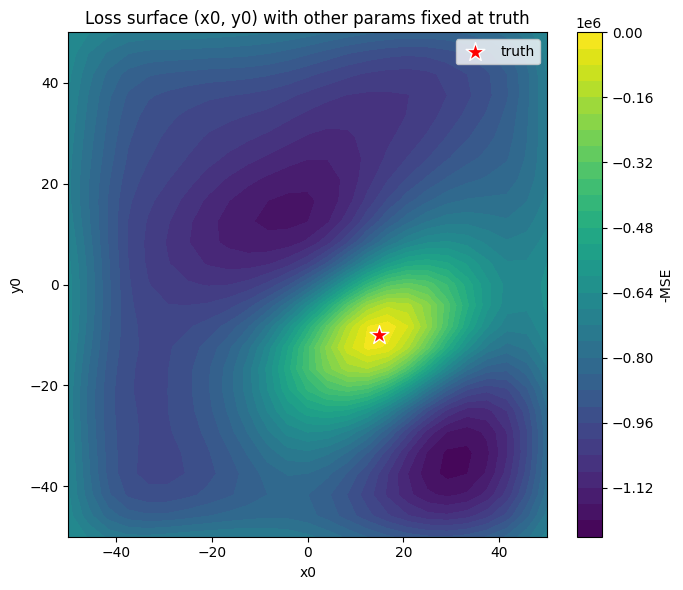

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Sweep x0 and y0, holding other params at truth
n_grid = 25
x0_range = np.linspace(-50, 50, n_grid)
y0_range = np.linspace(-50, 50, n_grid)
loss_surface = np.zeros((n_grid, n_grid))

theta_template = theta_true.clone()
for i, x0 in enumerate(x0_range):
    for j, y0 in enumerate(y0_range):
        theta = theta_template.clone()
        theta[0] = x0
        theta[1] = y0
        loss_surface[i, j] = blob_inversion_objective(theta.unsqueeze(0)).item()

plt.figure(figsize=(7, 6))
plt.contourf(x0_range, y0_range, loss_surface.T, levels=30, cmap='viridis')
plt.colorbar(label='-MSE')
plt.scatter([theta_true[0].item()], [theta_true[1].item()],
            c='red', marker='*', s=200, label='truth', edgecolors='white')
plt.xlabel('x0'); plt.ylabel('y0')
plt.title('Loss surface (x0, y0) with other params fixed at truth')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import UpperConfidenceBound
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.transforms import Standardize, Normalize

# Bounds: (x0, y0, z0, radius, log_amplitude)
bounds = torch.tensor([
    [-50.0, -50.0, -10.0, 2.0,  np.log(0.05)],   # lower
    [ 50.0,  50.0,  10.0, 20.0, np.log(2.0)],    # upper
], dtype=torch.float64)  # CPU/float64 for BoTorch

# Initial design: n_initial quasi-random points
torch.manual_seed(0)
n_initial = 10
train_x = (torch.rand(n_initial, 5, dtype=torch.float64)
           * (bounds[1] - bounds[0]) + bounds[0])
train_obj = torch.cat([blob_inversion_objective(x.unsqueeze(0)) for x in train_x])

print(f"True theta: {theta_true.cpu().numpy()}")
print(f"Initial best: {train_obj.max().item():.4e}")
print("-" * 60)

n_iter = 150
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i in range(n_iter):
        # Fit GP surrogate. Normalize inputs to [0,1], standardize outputs.
        model = SingleTaskGP(
            train_x, train_obj,
            input_transform=Normalize(d=5, bounds=bounds),
            outcome_transform=Standardize(m=1),
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)

        # UCB with mild exploration decay
        beta = max(0.3, 1.0 * (1 - i / n_iter))
        acq = UpperConfidenceBound(model, beta=beta)

        new_x, _ = optimize_acqf(
            acq, bounds=bounds, q=1, num_restarts=10, raw_samples=256,
        )
        new_obj = blob_inversion_objective(new_x)

        train_x = torch.cat([train_x, new_x])
        train_obj = torch.cat([train_obj, new_obj])

        best_idx = train_obj.argmax()
        best_x = train_x[best_idx]
        if (i + 1) % 5 == 0 or i == 0:
            print(f"Iter {i+1:02d}: best={train_obj.max().item():.4e}  "
                  f"theta=({best_x[0]:6.2f}, {best_x[1]:6.2f}, {best_x[2]:5.2f}, "
                  f"r={best_x[3]:5.2f}, log_a={best_x[4]:5.2f})")

best_idx = train_obj.argmax()
best_theta = train_x[best_idx]
print("\nRecovered:", best_theta.numpy())
print("True:     ", theta_true.cpu().numpy())

/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 32, 24, 24, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 32, 24, 24, 6]. This behavior is deprecated, and in a future PyTorch release outp

True theta: [ 15.        -10.         -3.          8.         -0.6931472]
Initial best: -5.1792e+05
------------------------------------------------------------
Iter 01: best=-5.1792e+05  theta=(  5.82,   8.75,  3.64, r=15.42, log_a=-2.16)
Iter 05: best=-5.1792e+05  theta=(  5.82,   8.75,  3.64, r=15.42, log_a=-2.16)
Iter 10: best=-5.1792e+05  theta=(  5.82,   8.75,  3.64, r=15.42, log_a=-2.16)
Iter 15: best=-5.1792e+05  theta=(  5.82,   8.75,  3.64, r=15.42, log_a=-2.16)
Iter 20: best=-5.1792e+05  theta=(  5.82,   8.75,  3.64, r=15.42, log_a=-2.16)
Iter 25: best=-5.1792e+05  theta=(  5.82,   8.75,  3.64, r=15.42, log_a=-2.16)
Iter 30: best=-4.9523e+05  theta=( 50.00,   2.36, -10.00, r= 8.00, log_a=-0.54)
Iter 35: best=-4.8331e+05  theta=( 50.00,  -0.60, -10.00, r= 6.81, log_a=-0.47)
Iter 40: best=-4.8210e+05  theta=( 50.00,  16.33, -10.00, r= 3.25, log_a=-0.14)
Iter 45: best=-4.8210e+05  theta=( 50.00,  16.33, -10.00, r= 3.25, log_a=-0.14)
Iter 50: best=-4.8089e+05  theta=( -1.16,  50

/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 32, 24, 24, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/Users/tantrik/Documents/GitHub/terra-demo/.venv/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 32, 24, 24, 6]. This behavior is deprecated, and in a future PyTorch release outp

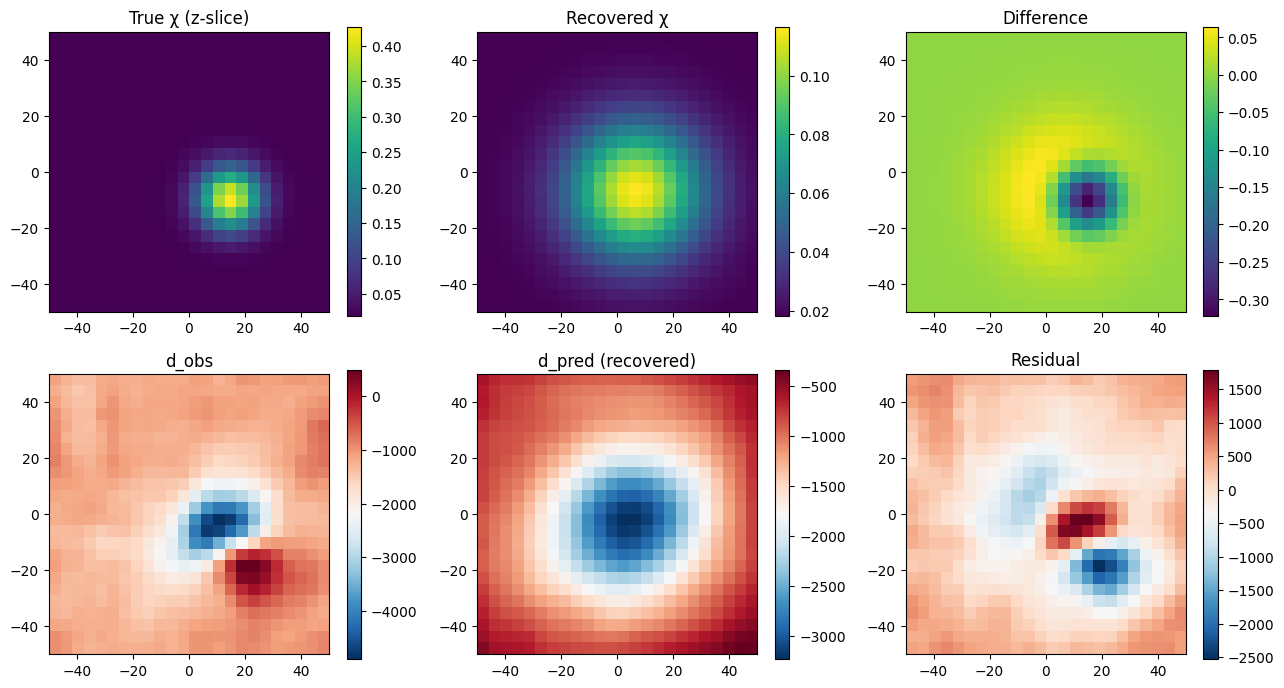

In [33]:
chi_recovered = make_blob_field(
    best_theta.to(device=device, dtype=torch.float32),
    grid_points_torch, grid_shape,
)
with torch.no_grad():
    d_recovered = fno(chi_recovered)[..., -1]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

# Top row: true field, recovered field, difference (z-slice through blob)
z_idx = grid_shape[2] // 2
chi_true_np = chi_true.squeeze().cpu().numpy()
chi_rec_np = chi_recovered.squeeze().cpu().numpy()

vmin = min(chi_true_np.min(), chi_rec_np.min())
vmax = max(chi_true_np.max(), chi_rec_np.max())

for ax, data, title in zip(
    axes[0],
    [chi_true_np[:, :, z_idx], chi_rec_np[:, :, z_idx],
     chi_rec_np[:, :, z_idx] - chi_true_np[:, :, z_idx]],
    ['True χ (z-slice)', 'Recovered χ', 'Difference'],
):
    im = ax.imshow(data.T, origin='lower', extent=(-50, 50, -50, 50), cmap='viridis')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

# Bottom row: d_obs, d_recovered, residual
d_obs_np = d_obs.squeeze().cpu().numpy()
d_rec_np = d_recovered.squeeze().cpu().numpy()

for ax, data, title in zip(
    axes[1],
    [d_obs_np, d_rec_np, d_rec_np - d_obs_np],
    ['d_obs', 'd_pred (recovered)', 'Residual'],
):
    im = ax.imshow(data.T, origin='lower', extent=(-50, 50, -50, 50), cmap='RdBu_r')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()